# Realistic simulation of VELOX thermal infrared channels

**Schäfer et al. (2022)**, *Atmos. Meas. Tech.*, 15, 1491–1509, https://doi.org/10.5194/amt-15-1491-2022

This notebook builds a **first-order forward model** for the six spectral channels of the VELOX thermal infrared imager, operating aboard the HALO research aircraft during the **HALO-(AC)³** campaign over Arctic sea ice.

The goals are:
* Translate a broadband thermal simulation into a **channel-resolved** forward model.
* Demonstrate the sensitivity of VELOX channels to **surface type, skin temperature, emissivity**, and **water-vapour column**.
* Introduce optional **instrument corrections** (Germanium window, channel Tmax, NEDT).
* Provide a **real-data anchor** using RF04 broadband VELOX observations.

> ⚠️ **Simplified model notice**: spectral response functions are approximated as top-hat filters using published wavelength bounds and peak transmissions. Surface emissivities are an educational parameterisation. No calibration chain or retrieval algorithm is implemented. Label this as a *first-order VELOX channel simulator*, not a validated forward model.

## 1. Why simulate VELOX channels?

A single broadband thermal simulation (7.7–12.0 µm) yields one integrated brightness temperature. VELOX observes the scene in **six channels** simultaneously. Channel differences contain independent information:

| Channel pair | Physical signal |
|---|---|
| CH3 (10.74 µm) − CH6 (12.00 µm) | Classic split-window: H₂O absorption, skin-T, emissivity |
| CH5 (11.66 µm) − CH6 (12.00 µm) | Narrower split-window |
| Broadband − narrowband | Atmospheric weighting function contrast |
| CH2 (8.65 µm) vs window channels | Cloud-top detection, cloud phase proxy |

A forward model that resolves these channels is the prerequisite for building retrievals and for interpreting VELOX imagery over sea ice.

In [1]:
import pyradtran  # registers ds.pyradtran accessor
from pyradtran import Var
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import numpy as np
import xarray as xr
from pathlib import Path
import pandas as pd
import logging
import warnings

logging.getLogger('pyradtran').setLevel(logging.CRITICAL)

plt.rcParams.update({
    'figure.dpi': 120,
    'axes.spines.top': False,
    'axes.spines.right': False,
})

print("pyradtran imported successfully.")

pyradtran imported successfully.


## 2. Instrument model

VELOX = **V**ideo airborn**E** **L**ongwave **O**bservations within si**X** channels.

* Sensor format: 640 × 512 px (post-processing uses 635 × 507 px for cross-filter comparability)
* Field of view: 35.5° × 28.7°
* Platform: HALO (Gulfstream G-550), typical survey altitude 8–12 km
* Mounted: nadir-looking
* Thermal range: 7.7–12.0 µm

The six filters are listed in the table below. **Spectral response functions (SRFs) are approximated as top-hat filters.** The hook `load_srf_or_tophat()` is provided so measured SRF CSV files can be dropped in later.

In [2]:
def make_velox_channels():
    """Return a DataFrame with VELOX channel definitions.

    Wavelength bounds are derived from Schäfer et al. (2022) Table 1
    (centre ± half-width). SRFs are *approximated* as top-hat filters;
    replace with measured SRF data when available.

    Returns
    -------
    pd.DataFrame
        Columns: channel, wl_min [nm], wl_max [nm], center_um, halfwidth_um,
        Tmax, label, ch_type.
    """
    rows = [
        # ch  wl_min  wl_max  center  hw     Tmax  label                type
        (1,  7700,  12000,  None,   None,  0.94, "CH1 Broadband",     "broadband"),
        (2,  8100,   9200,  8.65,   0.55,  0.89, "CH2 8.65 µm",       "narrowband"),
        (3, 10350,  11130, 10.74,   0.39,  0.83, "CH3 10.74 µm",      "narrowband"),
        (4,  7700,  12000,  None,   None,  0.94, "CH4 Broadband",     "broadband"),
        (5, 10850,  12470, 11.66,   0.81,  0.88, "CH5 11.66 µm",      "narrowband"),
        (6, 11500,  12500, 12.00,   0.50,  0.92, "CH6 12.00 µm",      "narrowband"),
    ]
    cols = ["channel", "wl_min", "wl_max", "center_um", "halfwidth_um",
            "Tmax", "label", "ch_type"]
    df = pd.DataFrame(rows, columns=cols)
    # Fill broadband centre as midpoint for reference only
    mask = df["center_um"].isna()
    df.loc[mask, "center_um"] = (df.loc[mask, "wl_min"] + df.loc[mask, "wl_max"]) / 2e3
    return df


channels = make_velox_channels()
print(channels[["channel", "wl_min", "wl_max", "center_um", "Tmax", "label"]].to_string(index=False))

 channel  wl_min  wl_max  center_um  Tmax         label
       1    7700   12000       9.85  0.94 CH1 Broadband
       2    8100    9200       8.65  0.89   CH2 8.65 µm
       3   10350   11130      10.74  0.83  CH3 10.74 µm
       4    7700   12000       9.85  0.94 CH4 Broadband
       5   10850   12470      11.66  0.88  CH5 11.66 µm
       6   11500   12500      12.00  0.92  CH6 12.00 µm


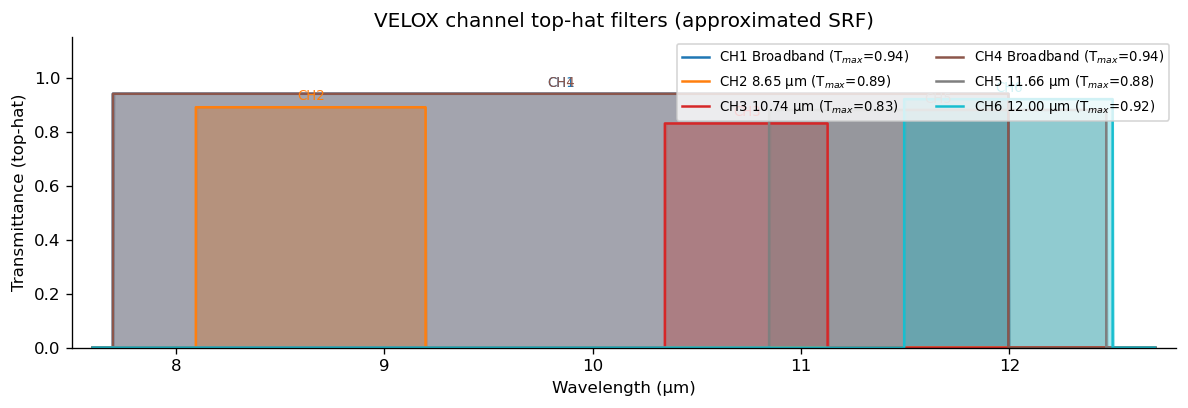

In [3]:
def plot_channel_response(channels_df, ax=None):
    """Plot top-hat channel response functions for all VELOX channels."""
    if ax is None:
        fig, ax = plt.subplots(figsize=(10, 3.5))
    else:
        fig = ax.get_figure()

    colors = plt.cm.tab10(np.linspace(0, 0.9, len(channels_df)))
    wl_grid = np.linspace(7600, 12700, 1000)  # nm

    for (_, ch), color in zip(channels_df.iterrows(), colors):
        response = np.where(
            (wl_grid >= ch["wl_min"]) & (wl_grid <= ch["wl_max"]),
            ch["Tmax"], 0.0
        )
        ax.fill_between(wl_grid / 1e3, 0, response, alpha=0.35, color=color)
        ax.step(wl_grid / 1e3, response, color=color, lw=1.5,
                label=f"{ch['label']} (T$_{{max}}$={ch['Tmax']:.2f})")
        # Annotate centre wavelength
        cx = ch["center_um"]
        ax.text(cx, ch["Tmax"] + 0.015, f"CH{int(ch['channel'])}",
                ha="center", va="bottom", fontsize=8, color=color)

    ax.set_xlabel("Wavelength (µm)")
    ax.set_ylabel("Transmittance (top-hat)")
    ax.set_xlim(7.5, 12.8)
    ax.set_ylim(0, 1.15)
    ax.legend(fontsize=8, ncol=2, loc="upper right")
    ax.set_title("VELOX channel top-hat filters (approximated SRF)")
    fig.tight_layout()
    return fig, ax


fig_ch, _ = plot_channel_response(channels)
plt.show()

In [4]:
def load_srf_or_tophat(channel_row, wl_grid_nm):
    """Return normalised SRF for a VELOX channel on *wl_grid_nm*.

    Currently returns a top-hat based on the published wavelength range
    and Tmax.  **Replace this function** to load measured SRF curves from
    a CSV file (columns: wavelength_nm, transmittance) when available.

    Parameters
    ----------
    channel_row : pd.Series
        One row from make_velox_channels().
    wl_grid_nm : array-like
        Wavelength grid in nm.

    Returns
    -------
    np.ndarray
        Normalised SRF (0-1) on wl_grid_nm.

    Example for real SRF
    --------------------
    # srf_df = pd.read_csv(f'srf_ch{int(channel_row.channel)}.csv')
    # return np.interp(wl_grid_nm, srf_df['wavelength_nm'], srf_df['transmittance'],
    #                  left=0, right=0)
    """
    wl = np.asarray(wl_grid_nm)
    return np.where(
        (wl >= channel_row["wl_min"]) & (wl <= channel_row["wl_max"]),
        channel_row["Tmax"], 0.0
    )

## 3. Scene definition: Arctic sea-ice case (HALO-AC³ RF04 context)

The scene is loosely based on HALO-(AC)³ Research Flight 04 (2022-03-14), a transit/survey flight over the Svalbard–sea-ice region.

**Atmosphere**: Standard US atmosphere with optional H₂O perturbation via `mol_modify`. For high-quality profiles, replace with ERA5 or radiosonde data (see `era5_atmosphere` and `era5_seasonal_sea_ice_profiles` notebooks).

**Surface types** (all approximate):

| Type | Skin temp | Emissivity | Note |
|---|---|---|---|
| Open water / lead | 271.35 K | 0.98 | Near freezing point of saline water |
| Snow-covered sea ice | 253 K | 0.99 | Cold Arctic sea ice |
| Thin/bare ice | 265 K | 0.95 | Transitional, more variable emissivity |

> ⚠️ Emissivities here are rough educational values. Real VELOX retrievals require spectrally resolved emissivity spectra (e.g., from laboratory databases or the ASTER spectral library).

In [5]:
# ── Scene constants ────────────────────────────────────────────────────────────
LAT         = 78.9          # °N  — Svalbard / Fram Strait
LON         = 12.4          # °E
BASE_TIME   = "2022-03-14T12:00:00"
ALT_KM      = 10.0          # aircraft altitude (km)
H2O_DRY_MM  = 5.0           # precipitable water, dry Arctic (mm)
H2O_MOIST_MM= 20.0          # moist Arctic case

# ── Surface type definitions ───────────────────────────────────────────────────
# emissivity: approximate spectrally flat value (Kirchhoff: albedo = 1 - emissivity)
SURFACE_TYPES = {
    "open_water":  {"T_sfc": 271.35, "emissivity": 0.98},
    "snow_ice":    {"T_sfc": 253.15, "emissivity": 0.99},
    "thin_ice":    {"T_sfc": 265.00, "emissivity": 0.95},
}

print("Surface types:")
for name, props in SURFACE_TYPES.items():
    print(f"  {name:16s}  T_sfc={props['T_sfc']:.2f} K  "
          f"ε={props['emissivity']:.2f}  albedo={1-props['emissivity']:.2f}")

Surface types:
  open_water        T_sfc=271.35 K  ε=0.98  albedo=0.02
  snow_ice          T_sfc=253.15 K  ε=0.99  albedo=0.01
  thin_ice          T_sfc=265.00 K  ε=0.95  albedo=0.05


In [6]:
def make_surface_emissivity(surface_type_name, wl_um=None):
    """Return approximate spectrally flat emissivity for a surface type.

    This is an educational simplification. In reality:
    - Snow emissivity drops near 11–12 µm (ε ≈ 0.97–0.99)
    - Seawater emissivity is ~0.98–0.99 across 8–13 µm
    - Bare ice can be significantly lower and more spectrally variable

    Replace this function or the SURFACE_TYPES dict with spectrally resolved
    values from the ASTER spectral library, Salisbury & D'Aria (1994), or
    in-situ measurements when available.

    Parameters
    ----------
    surface_type_name : str
        Key in SURFACE_TYPES dict.
    wl_um : array-like, optional
        Wavelength grid (µm). Ignored for flat emissivity; kept as hook.

    Returns
    -------
    float
        Emissivity (0–1).
    """
    return SURFACE_TYPES[surface_type_name]["emissivity"]


def load_surface_emissivity_csv(path, wl_um):
    """Load spectral emissivity from a two-column CSV file.

    **Stub** — not yet implemented. Replace the body with:

    >>> df = pd.read_csv(path)
    >>> return np.interp(wl_um, df['wavelength_um'], df['emissivity'],
    ...                  left=df['emissivity'].iloc[0],
    ...                  right=df['emissivity'].iloc[-1])

    Parameters
    ----------
    path : str or Path
        CSV file with columns 'wavelength_um' and 'emissivity'.
    wl_um : array-like
        Target wavelength grid in µm.
    """
    raise NotImplementedError(
        f"Implement load_surface_emissivity_csv to read {path} "
        "and interpolate to wl_um."
    )

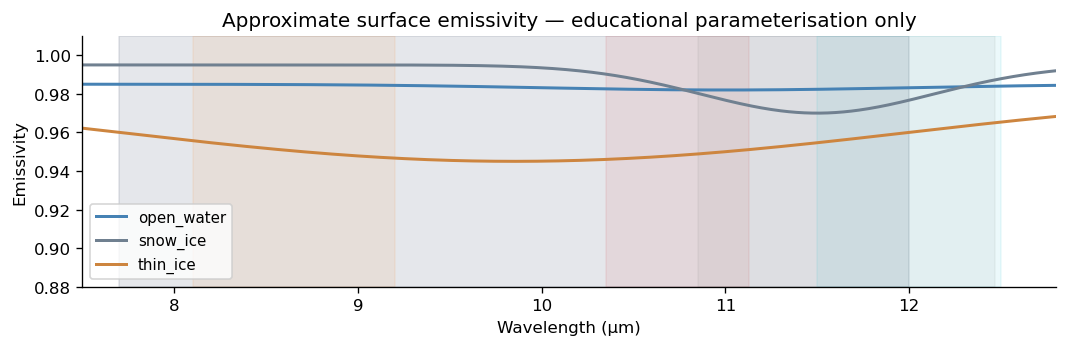

In [7]:
fig_em, ax_em = plt.subplots(figsize=(9, 3))

# Approximate spectral profiles for illustration
wl_plot = np.linspace(7.5, 12.8, 500)  # µm

# These are illustrative piecewise functions — NOT real measured spectra
def _eps_water(wl):
    return np.clip(0.985 - 0.003 * np.exp(-((wl - 11.0)**2) / 2), 0.96, 1.0)

def _eps_snow(wl):
    drop = np.exp(-((wl - 11.5)**2) / 0.8)
    return np.clip(0.995 - 0.025 * drop, 0.965, 1.0)

def _eps_thin_ice(wl):
    return np.clip(0.96 - 0.015 * np.sin(np.pi * (wl - 7.7) / 4.3), 0.90, 0.97)

profiles = {
    "open_water":  (_eps_water,  "steelblue"),
    "snow_ice":    (_eps_snow,   "slategray"),
    "thin_ice":    (_eps_thin_ice, "peru"),
}
for name, (fn, col) in profiles.items():
    ax_em.plot(wl_plot, fn(wl_plot), color=col, lw=1.8, label=name)

# Shade VELOX bands for reference
ch_colors = plt.cm.tab10(np.linspace(0, 0.9, len(channels)))
for (_, ch), col in zip(channels.iterrows(), ch_colors):
    ax_em.axvspan(ch["wl_min"]/1e3, ch["wl_max"]/1e3, alpha=0.08, color=col)

ax_em.set_xlabel("Wavelength (µm)")
ax_em.set_ylabel("Emissivity")
ax_em.set_xlim(7.5, 12.8)
ax_em.set_ylim(0.88, 1.01)
ax_em.legend(fontsize=9)
ax_em.set_title("Approximate surface emissivity — educational parameterisation only")
fig_em.tight_layout()
plt.show()

## 4. Radiative transfer setup

Each VELOX channel is simulated as an **integrated band radiance / brightness temperature** over its top-hat wavelength window using libRadtran/pyRadtran with:

* `source thermal` + `output_process integrate` → wavelength-integrated upwelling BT  
* `output_quantity brightness` → output in Kelvin  
* `reptran medium` → moderate correlated-k accuracy  
* Per-channel wavelength range passed via `params={'wavelength': 'wl_min wl_max'}`  
* Surface emissivity entered as `albedo = 1 − ε` (libRadtran sign convention)

The function `run_velox_channel_scene` iterates over all 6 channels and collects results into one xarray Dataset with dimensions `(channel, surface_type, altitude)`.

In [8]:
# ── Config ─────────────────────────────────────────────────────────────────────
CONFIG_PATH = Path("config/velox_realistic.yaml")
assert CONFIG_PATH.exists(), f"Config not found: {CONFIG_PATH.resolve()}"

# Set RUN_EXPENSIVE = True to run full H₂O sweep and cloud case.
# The default run is: 6 channels × 3 surface types × 2 H₂O values = 36 simulations.
RUN_EXPENSIVE = False

In [9]:
def run_velox_channel_scene(
    channels_df,
    surface_types,
    config_path,
    h2o_mm=5.0,
    aircraft_altitude_km=10.0,
    lat=LAT,
    lon=LON,
    base_time=BASE_TIME,
    mol_abs_param=None,
):
    """Run a per-channel VELOX forward simulation over multiple surface types.

    For each VELOX channel the wavelength range is overridden at runtime via
    ``params={'wavelength': 'wl_min wl_max'}``.  All other
    settings come from *config_path* (velox_realistic.yaml).

    Parameters
    ----------
    channels_df : pd.DataFrame
        VELOX channel table from ``make_velox_channels()``.
    surface_types : dict
        ``{name: {'T_sfc': float, 'emissivity': float}}``.
    config_path : Path
        YAML config file path.
    h2o_mm : float
        Precipitable water column in mm (``mol_modify H2O``).
    aircraft_altitude_km : float
        Output altitude (zout) in km — corresponds to aircraft level.
    lat, lon : float
        Scene location (°N, °E).
    base_time : str
        ISO-format UTC timestamp.
    mol_abs_param : str, optional
        Override ``mol_abs_param`` (e.g. 'reptran coarse' for speed).

    Returns
    -------
    xr.Dataset
        Dimensions ``(channel, surface_type, altitude)``.
        Key variable: ``eup`` — upwelling brightness temperature in K.
    """
    stype_names = list(surface_types.keys())
    T_sfcs   = [surface_types[s]["T_sfc"]                  for s in stype_names]
    albedos  = [1.0 - surface_types[s]["emissivity"]       for s in stype_names]

    # One time step per surface type so (T_sfc, albedo) pairs are preserved
    times = pd.date_range(base_time, periods=len(stype_names), freq="s")

    ds_input = xr.Dataset(
        coords={
            "time":      times,
            "latitude":  ("time", [lat] * len(stype_names)),
            "longitude": ("time", [lon] * len(stype_names)),
            "altitude":  ("altitude", [aircraft_altitude_km]),
        },
        data_vars={
            "surface_temperature": ("time", T_sfcs),
            "albedo":              ("time", albedos),
        },
    )

    # Build base overrides
    base_overrides = {
        "output_quantity": "brightness",
        "mol_modify H2O ": f"{h2o_mm} MM",
    }
    if mol_abs_param is not None:
        base_overrides["mol_abs_param"] = mol_abs_param

    channel_results = []
    for _, ch in channels_df.iterrows():
        overrides = {**base_overrides,
                     "wavelength": f"{int(ch['wl_min'])} {int(ch['wl_max'])}"}

        ds_ch = ds_input.pyradtran.run(
            config_path=config_path,
            return_dataset=True,
            save_to_file=True,
            params={'sur_temperature': Var('surface_temperature'), 'albedo': Var('albedo'), **overrides},
            show_progress=False,
        )

        # Label the time dimension with surface type names
        ds_ch = ds_ch.assign_coords(time=stype_names).rename({"time": "surface_type"})
        channel_results.append(ds_ch)

    ds_all = xr.concat(channel_results, dim="channel")
    ds_all = ds_all.assign_coords(channel=channels_df["channel"].values)

    # Attach channel metadata as coordinate
    ds_all = ds_all.assign_coords(
        channel_label=("channel", channels_df["label"].values),
        Tmax=("channel", channels_df["Tmax"].values),
        wl_min_nm=("channel", channels_df["wl_min"].values),
        wl_max_nm=("channel", channels_df["wl_max"].values),
    )
    ds_all.attrs.update({
        "h2o_mm":          h2o_mm,
        "aircraft_alt_km": aircraft_altitude_km,
        "lat": lat, "lon": lon,
        "srf_type": "top-hat (Tmax applied as uniform transmittance)",
    })
    return ds_all

In [10]:
# ── Default run: dry Arctic atmosphere (H₂O = 5 mm) ──────────────────────────
print("Running 6 channels × 3 surface types (dry Arctic, H₂O = 5 mm)...")
ds_dry = run_velox_channel_scene(
    channels, SURFACE_TYPES, CONFIG_PATH, h2o_mm=H2O_DRY_MM
)

# ── Moist Arctic (H₂O = 20 mm) for split-window sensitivity ──────────────────
print("Running 6 channels × 3 surface types (moist Arctic, H₂O = 20 mm)...")
ds_moist = run_velox_channel_scene(
    channels, SURFACE_TYPES, CONFIG_PATH, h2o_mm=H2O_MOIST_MM
)

print("Done.")

Running 6 channels × 3 surface types (dry Arctic, H₂O = 5 mm)...
Running 6 channels × 3 surface types (moist Arctic, H₂O = 20 mm)...
Done.


In [11]:
# The eup variable contains upwelling brightness temperature at aircraft altitude
# Dimensions: (channel=6, surface_type=3, altitude=1)
print("=== Dry Arctic simulation dataset ===")
print(ds_dry)
print()
print("eup (BT in K) at aircraft altitude, dry Arctic:")
print(ds_dry.eup.isel(altitude=0).to_pandas())

=== Dry Arctic simulation dataset ===
<xarray.Dataset> Size: 1kB
Dimensions:        (channel: 6, altitude: 1, surface_type: 3)
Coordinates:
  * altitude       (altitude) int64 8B 0
  * surface_type   (surface_type) <U10 120B 'open_water' 'snow_ice' 'thin_ice'
  * channel        (channel) int64 48B 1 2 3 4 5 6
    channel_label  (channel) object 48B 'CH1 Broadband' ... 'CH6 12.00 µm'
    Tmax           (channel) float64 48B 0.94 0.89 0.83 0.94 0.88 0.92
    wl_min_nm      (channel) int64 48B 7700 8100 10350 7700 10850 11500
    wl_max_nm      (channel) int64 48B 12000 9200 11130 12000 12470 12500
Data variables:
    zout           (channel, altitude, surface_type) float64 144B 10.0 ... 10.0
    lambda         (channel, altitude, surface_type) float64 144B 7.707e+03 ....
    eup            (channel, altitude, surface_type) float64 144B 269.5 ... 2...
    edn            (channel, altitude, surface_type) float64 144B 162.7 ... 1...
    edir           (channel, altitude, surface_type) float

## 5. Instrument effects

Three first-order corrections are implemented:

### 5a. Tmax correction (filter peak transmittance)
The libRadtran simulation assumes 100% filter transmission over the channel bandwidth.  In reality, the channel has a peak transmittance $T_{\max} < 1$. In radiance space:
$$L_{\mathrm{eff}} = T_{\max} \cdot L_{\mathrm{scene}} + (1 - T_{\max}) \cdot L_{\mathrm{self}}$$
where $L_{\mathrm{self}}$ is the self-emission of the cold filter (≈ 0 for a cryogenically cooled detector).  Here we use a linearised brightness-temperature approximation at the channel's effective wavelength.

> ⚠️ The linearisation is a rough approximation, especially for broadband channels.

### 5b. Germanium window correction
VELOX uses a Germanium entrance window with transmittance $\tau_{\mathrm{win}} \approx 0.9395$. The measured radiance is:
$$L_{\mathrm{meas}} = \tau_{\mathrm{win}} \cdot L_{\mathrm{upwelling}} + (1 - \tau_{\mathrm{win}}) \cdot B(\lambda_{\mathrm{eff}}, T_{\mathrm{win}})$$
Here $T_{\mathrm{win}}$ is the window physical temperature (~293 K inside the aircraft cabin). This introduces a warm offset. The correction is applied in radiance space and inverted to brightness temperature.

> ⚠️ In practice $\tau_{\mathrm{win}}$ is wavelength-dependent; a single constant is used here as a first-order correction.

### 5c. NEDT noise
NEDT ≈ 0.04 K (representative lab value for VELOX). Added as Gaussian noise.

In [12]:
# Physical constants
_h  = 6.62607015e-34  # J s
_c  = 2.99792458e8    # m/s
_kb = 1.380649e-23    # J/K


def planck_radiance(T_K, wl_um):
    """Spectral radiance [W m⁻² sr⁻¹ µm⁻¹] from Planck's law.

    Parameters
    ----------
    T_K : float or array
        Temperature in Kelvin.
    wl_um : float or array
        Wavelength in µm.
    """
    wl_m = np.asarray(wl_um) * 1e-6
    T    = np.asarray(T_K)
    exponent = (_h * _c) / (wl_m * _kb * T)
    return (2 * _h * _c**2 / wl_m**5) / (np.exp(exponent) - 1) * 1e-6  # µm⁻¹


def brightness_temperature(L_wm2sr_um, wl_um):
    """Invert Planck's law: radiance [W m⁻² sr⁻¹ µm⁻¹] → brightness temperature [K]."""
    wl_m = np.asarray(wl_um) * 1e-6
    L    = np.asarray(L_wm2sr_um)
    return (_h * _c) / (wl_m * _kb * np.log(1 + (2 * _h * _c**2) / (wl_m**5 * L * 1e6)))

In [13]:
TAU_WINDOW   = 0.9395   # Germanium window transmittance (constant, first-order)
T_WINDOW_K   = 293.15   # Window physical temperature (cabin ~20°C)
NEDT_K       = 0.04     # Noise-equivalent temperature difference (K)


def apply_window_correction(BT_K, wl_eff_um, tau=TAU_WINDOW, T_win=T_WINDOW_K):
    """Apply Germanium window transmission correction.

    Works in radiance space at the channel's effective wavelength.

    Lmeas = tau * L_scene + (1-tau) * B(wl_eff, T_win)
    BT_corrected = B_inv(Lmeas, wl_eff)

    Parameters
    ----------
    BT_K : float or array
        Scene brightness temperature before window (K).
    wl_eff_um : float
        Channel effective wavelength (µm).
    tau : float
        Window transmittance.
    T_win : float
        Window physical temperature (K).

    Returns
    -------
    np.ndarray
        Corrected brightness temperature (K).

    Warnings
    --------
    tau is wavelength-independent here — a first-order approximation only.
    """
    L_scene = planck_radiance(BT_K, wl_eff_um)
    L_win   = planck_radiance(T_win, wl_eff_um)
    L_meas  = tau * L_scene + (1 - tau) * L_win
    return brightness_temperature(L_meas, wl_eff_um)


def apply_tmax_correction(BT_K, Tmax, wl_eff_um, T_filter_K=80.0):
    """Apply peak filter transmittance correction (linearised).

    Leff = Tmax * L_scene + (1-Tmax) * B(wl_eff, T_filter)
    For a cold (cryogenically cooled) detector, T_filter ≈ 80 K so the
    self-emission term is negligible. For an uncooled detector, use
    the actual filter temperature.

    Warnings
    --------
    Linearisation is approximate, especially for broadband channels.
    """
    L_scene = planck_radiance(BT_K, wl_eff_um)
    L_self  = planck_radiance(T_filter_K, wl_eff_um)
    L_eff   = Tmax * L_scene + (1 - Tmax) * L_self
    return brightness_temperature(L_eff, wl_eff_um)


def add_nedt_noise(BT_K, nedt_k=NEDT_K, seed=42):
    """Add Gaussian NEDT noise to a brightness temperature array."""
    rng = np.random.default_rng(seed)
    return np.asarray(BT_K) + rng.normal(0.0, nedt_k, size=np.asarray(BT_K).shape)

In [14]:
# ── Apply all corrections to the dry-Arctic run ───────────────────────────────
BT_raw     = ds_dry.eup.isel(altitude=0).values   # shape (channel, surface_type)
BT_corrected = np.empty_like(BT_raw)

for i, (_, ch) in enumerate(channels.iterrows()):
    wl_eff = ch["center_um"]
    bt = BT_raw[i]
    bt = apply_tmax_correction(bt, ch["Tmax"], wl_eff)
    bt = apply_window_correction(bt, wl_eff)
    BT_corrected[i] = bt

# Build a corrected xarray DataArray
BT_corrected_da = xr.DataArray(
    BT_corrected,
    dims=["channel", "surface_type"],
    coords={
        "channel":       ds_dry.channel.values,
        "surface_type":  ds_dry.surface_type.values,
        "channel_label": ("channel", ds_dry.channel_label.values),
    },
    attrs={"units": "K", "description": "Tmax + Ge-window corrected BT"},
)

# Delta BT due to corrections
delta_BT = BT_corrected - BT_raw
print("BT correction (corrected − raw) in K:")
print(pd.DataFrame(delta_BT.round(3),
                   index=channels["label"],
                   columns=list(SURFACE_TYPES.keys())))

BT correction (corrected − raw) in K:
               open_water  snow_ice  thin_ice
label                                        
CH1 Broadband      -1.141     0.468    -0.477
CH2 8.65 µm        -3.009    -1.057    -2.222
CH3 10.74 µm       -7.434    -4.844    -6.319
CH4 Broadband      -1.141     0.468    -0.477
CH5 11.66 µm       -5.261    -3.107    -4.319
CH6 12.00 µm       -3.096    -1.284    -2.303


## 6. Diagnostics and plots

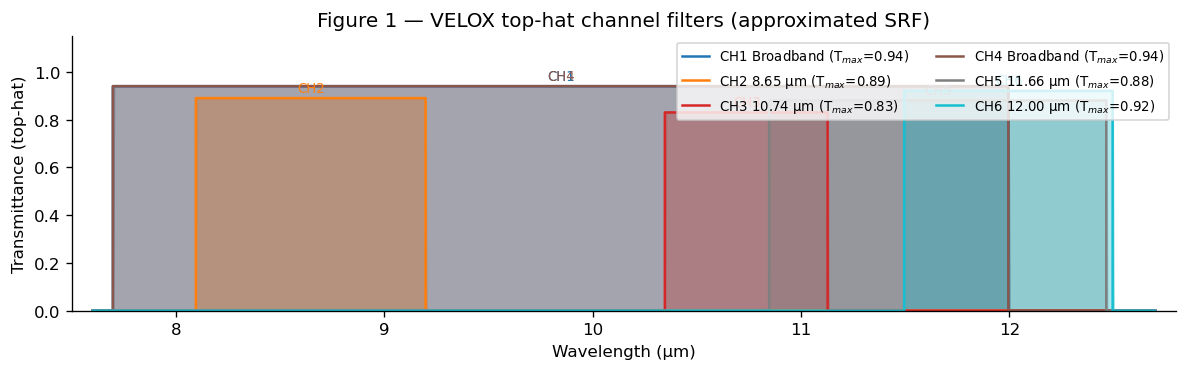

In [15]:
# ── Figure 1: Channel response (already shown above, reproduced for reference) ─
fig1, ax1 = plt.subplots(figsize=(10, 3.2))
plot_channel_response(channels, ax=ax1)
ax1.set_title("Figure 1 — VELOX top-hat channel filters (approximated SRF)")
plt.tight_layout()
plt.show()

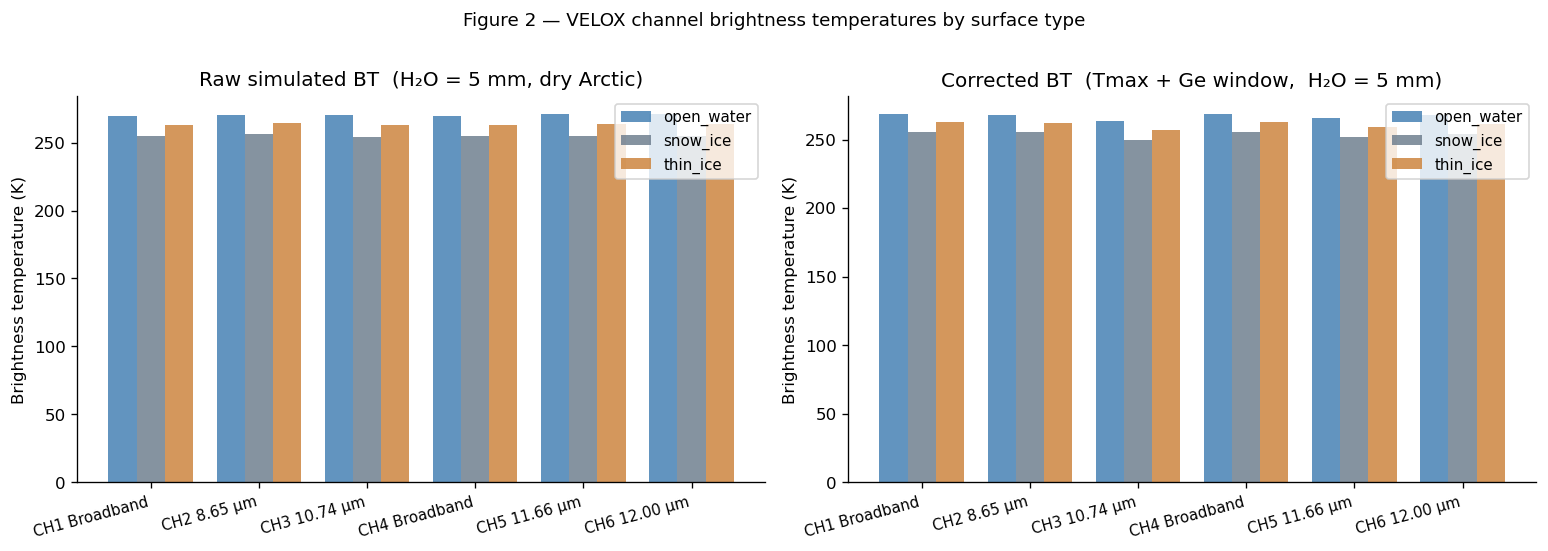

In [16]:
# ── Figure 2: Brightness temperature per channel and surface type ──────────────
fig2, axes2 = plt.subplots(1, 2, figsize=(13, 4.5), sharey=False)

ch_labels    = channels["label"].tolist()
stype_labels = list(SURFACE_TYPES.keys())
x            = np.arange(len(ch_labels))
width        = 0.26
stype_colors = {"open_water": "steelblue", "snow_ice": "slategray", "thin_ice": "peru"}

# Left panel: raw (libRadtran BT)
ax = axes2[0]
for j, stype in enumerate(stype_labels):
    vals = ds_dry.eup.isel(altitude=0).sel(surface_type=stype).values
    ax.bar(x + (j - 1) * width, vals, width, label=stype,
           color=stype_colors[stype], alpha=0.85)
ax.set_xticks(x);  ax.set_xticklabels(ch_labels, rotation=15, ha="right", fontsize=9)
ax.set_ylabel("Brightness temperature (K)")
ax.set_title("Raw simulated BT  (H₂O = 5 mm, dry Arctic)")
ax.legend(fontsize=9)

# Right panel: corrected (Tmax + window)
ax = axes2[1]
for j, stype in enumerate(stype_labels):
    vals = BT_corrected_da.sel(surface_type=stype).values
    ax.bar(x + (j - 1) * width, vals, width, label=stype,
           color=stype_colors[stype], alpha=0.85)
ax.set_xticks(x);  ax.set_xticklabels(ch_labels, rotation=15, ha="right", fontsize=9)
ax.set_ylabel("Brightness temperature (K)")
ax.set_title("Corrected BT  (Tmax + Ge window,  H₂O = 5 mm)")
ax.legend(fontsize=9)

fig2.suptitle("Figure 2 — VELOX channel brightness temperatures by surface type",
              fontsize=11, y=1.01)
fig2.tight_layout()
plt.show()

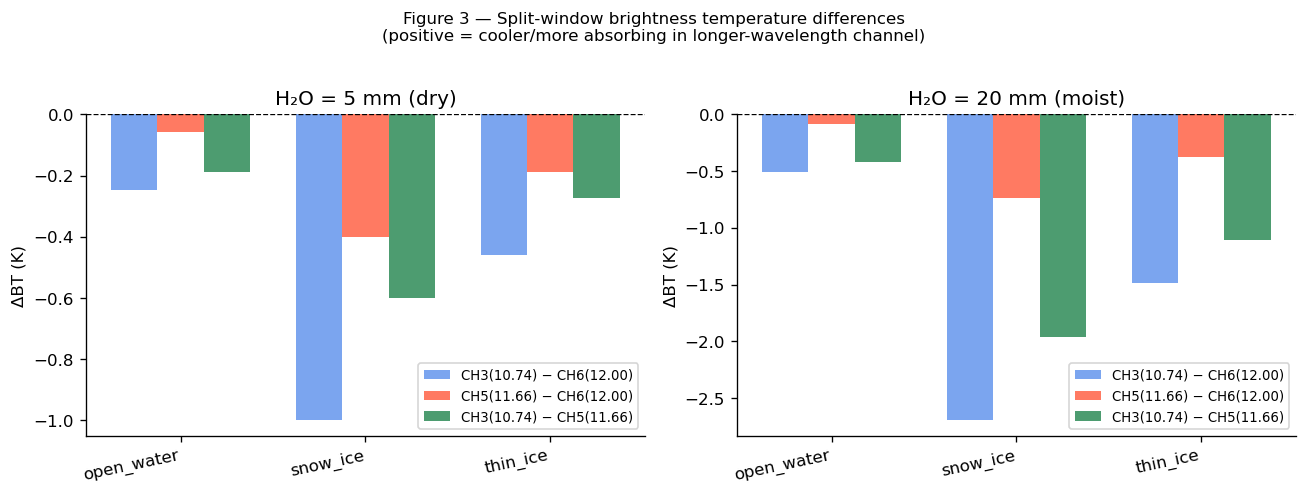

In [17]:
# ── Figure 3: Split-window brightness temperature differences ──────────────────
# Physical basis: CH3 (10.74 µm) and CH5 (11.66 µm) experience less H₂O absorption
# than CH6 (12.00 µm). The difference BT_CH3 - BT_CH6 is the classic split-window
# signal, sensitive to total column H₂O and surface emissivity.

fig3, axes3 = plt.subplots(1, 2, figsize=(11, 4))

# Retrieve BT at aircraft altitude (dry and moist)
BT_dry   = ds_dry.eup.isel(altitude=0)
BT_moist = ds_moist.eup.isel(altitude=0)

# Split-window pairs: (ch_a, ch_b) → ΔBT = BT_a - BT_b
sw_pairs = [
    (3, 6, "CH3(10.74) − CH6(12.00)", "cornflowerblue"),
    (5, 6, "CH5(11.66) − CH6(12.00)", "tomato"),
    (3, 5, "CH3(10.74) − CH5(11.66)", "seagreen"),
]

for ax, (BT, h2o_label) in zip(axes3, [(BT_dry, "H₂O = 5 mm (dry)"),
                                        (BT_moist, "H₂O = 20 mm (moist)")]):
    xpos = np.arange(len(stype_labels))
    for k, (cha, chb, lbl, col) in enumerate(sw_pairs):
        diffs = (BT.sel(channel=cha) - BT.sel(channel=chb)).values
        ax.bar(xpos + (k-1)*0.25, diffs, 0.25, label=lbl, color=col, alpha=0.85)

    ax.axhline(0, color="k", lw=0.8, ls="--")
    ax.set_xticks(xpos)
    ax.set_xticklabels(stype_labels, rotation=12, ha="right")
    ax.set_ylabel("ΔBT (K)")
    ax.set_title(f"{h2o_label}")
    ax.legend(fontsize=8)

fig3.suptitle(
    "Figure 3 — Split-window brightness temperature differences\n"
    "(positive = cooler/more absorbing in longer-wavelength channel)",
    fontsize=10, y=1.02
)
fig3.tight_layout()
plt.show()

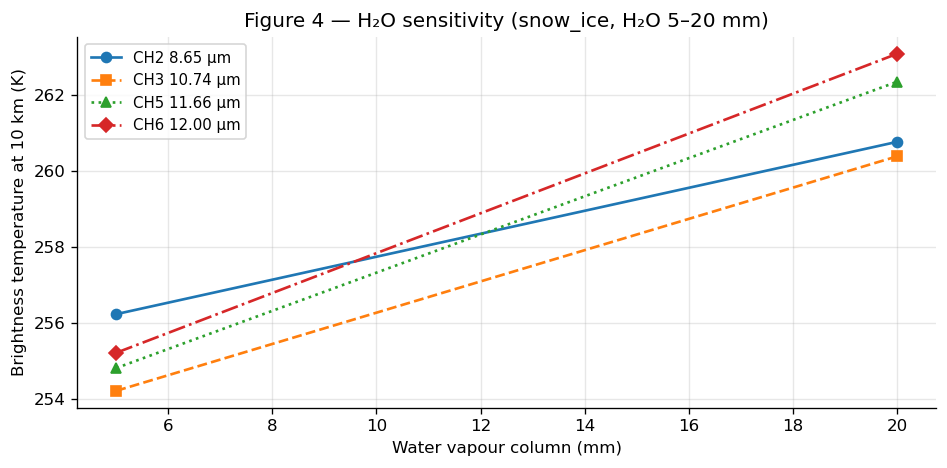

/tmp/ipykernel_26243/2531444816.py:40: UserWarning: Figure 4 shows only two H₂O values (5 and 20 mm). Set RUN_EXPENSIVE = True for the full 0–35 mm sweep.
  warnings.warn(


In [18]:
# ── Figure 4: H₂O sensitivity ─────────────────────────────────────────────────
# For the default run we compare two H₂O values (5 mm vs 20 mm).
# With RUN_EXPENSIVE = True the full sweep 0-35 mm is computed.

if RUN_EXPENSIVE:
    h2o_vals = np.arange(0, 40, 5)
    ds_h2o_list = []
    for h2o in h2o_vals:
        print(f"  H₂O = {h2o} mm ...")
        ds_h2o_list.append(
            run_velox_channel_scene(channels, SURFACE_TYPES, CONFIG_PATH, h2o_mm=h2o)
        )
    ds_h2o = xr.concat(ds_h2o_list, dim="h2o_mm")
    ds_h2o = ds_h2o.assign_coords(h2o_mm=h2o_vals.astype(float))
else:
    # Use the two already-computed cases
    ds_h2o = xr.concat([ds_dry, ds_moist], dim="h2o_mm")
    ds_h2o = ds_h2o.assign_coords(h2o_mm=[H2O_DRY_MM, H2O_MOIST_MM])

# Plot BT as function of H₂O for selected narrowband channels over snow_ice
fig4, ax4 = plt.subplots(figsize=(8, 4))
selected_channels = [2, 3, 5, 6]
ch_line_styles    = ["-o", "--s", ":^", "-.D"]
stype_plot = "snow_ice"

for ch_id, ls in zip(selected_channels, ch_line_styles):
    lbl = channels.loc[channels["channel"] == ch_id, "label"].values[0]
    y   = ds_h2o.eup.isel(altitude=0).sel(channel=ch_id, surface_type=stype_plot).values
    ax4.plot(ds_h2o.h2o_mm.values, y, ls, lw=1.6, ms=6, label=lbl)

ax4.set_xlabel("Water vapour column (mm)")
ax4.set_ylabel("Brightness temperature at 10 km (K)")
ax4.set_title(f"Figure 4 — H₂O sensitivity ({stype_plot}, H₂O 5–20 mm)")
ax4.legend(fontsize=9)
ax4.grid(True, alpha=0.3)
fig4.tight_layout()
plt.show()

if not RUN_EXPENSIVE:
    warnings.warn(
        "Figure 4 shows only two H₂O values (5 and 20 mm). "
        "Set RUN_EXPENSIVE = True for the full 0–35 mm sweep.",
        UserWarning, stacklevel=1
    )

## 7. Real VELOX data — HALO-(AC)³ RF04 (2022-03-14)

The training zarr file (`train_velox_correction.zarr`) contains broadband VELOX (CH1/CH4, 7.70–12.00 µm) brightness temperatures in °C from RF04, along with the per-pixel cosine of the view zenith angle (`cos_vza`), the non-uniformity correction term (`local_delta`), and the internal body temperatures (`T3`, `T4`, used in the non-uniformity correction).

All variables are stored as a flat 1-D array indexed by `n_samples`.  The image size is **635 × 507 pixels** after cross-filter normalisation (see `comment_4` in the zarr global attributes).

This section compares the nadir-centre BT from the real observation with our simulated broadband CH1 values to sanity-check the model.

> 📝 The zarr file is **not** bundled with the pyRadtran repository. If the file is not found at `~/Downloads/train_velox_correction.zarr`, this section is skipped automatically (docs CI fallback).

In [19]:
DATA_PATH = Path.home() / "Downloads" / "train_velox_correction.zarr"
IMG_ROWS, IMG_COLS = 507, 635   # from .zattrs comment_4
FRAME_SIZE = IMG_ROWS * IMG_COLS

HAS_REAL_DATA = DATA_PATH.exists()

if HAS_REAL_DATA:
    try:
        import zarr
        z = zarr.open(str(DATA_PATH), mode="r")
        print(f"Opened zarr: {DATA_PATH}")
        print(f"  Variables : {list(z.keys())}")
        print(f"  n_samples : {z['n_samples'].shape[0]:,}")
        n_frames = z["n_samples"].shape[0] // FRAME_SIZE
        print(f"  Frames    : {n_frames}  ({IMG_ROWS} × {IMG_COLS} px each)")
    except Exception as e:
        print(f"Could not open zarr: {e}")
        HAS_REAL_DATA = False
else:
    print(f"Real VELOX data not found at {DATA_PATH}.")
    print("Skipping real-data comparison sections (docs CI fallback).")

Opened zarr: /home/josh/Downloads/train_velox_correction.zarr
  Variables : ['BT_2D', 'T3', 'T4', 'cos_vza', 'local_delta', 'n_samples']
  n_samples : 145,841,085
  Frames    : 453  (507 × 635 px each)


In [29]:
ds = xr.open_dataset(DATA_PATH, engine="zarr")
ds

<xarray.Dataset> Size: 6GB
Dimensions:      (n_samples: 145841085)
Coordinates:
  * n_samples    (n_samples) int64 1GB 0 1 2 3 ... 145841082 145841083 145841084
Data variables:
    BT_2D        (n_samples) float32 583MB ...
    T3           (n_samples) float64 1GB ...
    T4           (n_samples) float64 1GB ...
    cos_vza      (n_samples) float64 1GB ...
    local_delta  (n_samples) float32 583MB ...
Attributes: (12/21)
    Conventions:             "CF-1.8"
    author:                  Michael Schäfer, Sophie Rosenburg, André Ehrlich...
    campaign:                HALO-AC3
    comment_1:               Band wavelength range: 7.70 - 12.00 micrometers
    comment_2:               Flight direction is towards positive y-direction...
    comment_3:               Thermal infrared imager information: focal lengt...
    ...                      ...
    research_flight_day:     20220314
    research_flight_number:  RF04
    source:                  Airborne imaging with the VELOX system
    title:                   Two-dimensional cloud-top or surface brightness ...
    variable:                BT_2D, BT_Center
    version:                 Version v3.0 from 2023-09-11

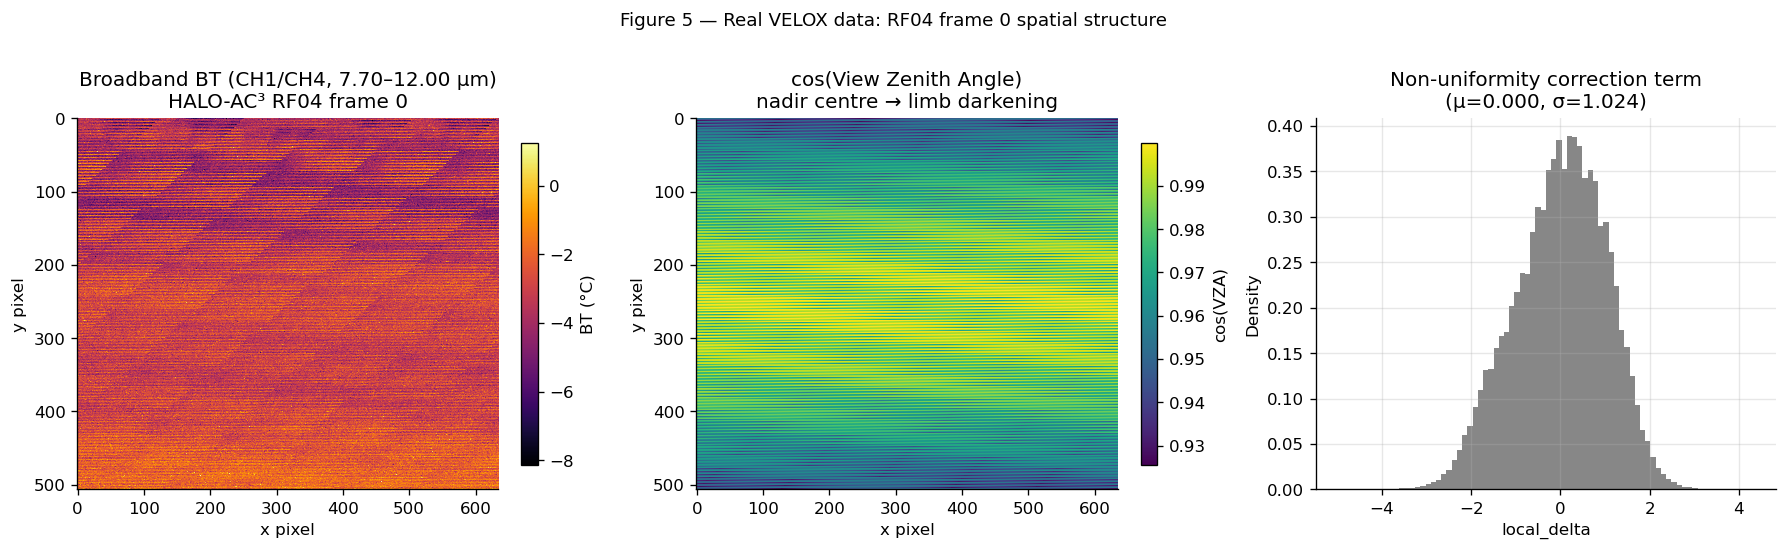

In [20]:
if HAS_REAL_DATA:
    # Load first frame (index 0)
    sl = slice(0, FRAME_SIZE)
    BT_2D_frame  = z["BT_2D"][sl].reshape(IMG_ROWS, IMG_COLS)   # °C
    cos_vza_frame = z["cos_vza"][sl].reshape(IMG_ROWS, IMG_COLS)
    local_delta_frame = z["local_delta"][sl].reshape(IMG_ROWS, IMG_COLS)

    # Build xarray DataArray for convenient plotting
    frame_da = xr.DataArray(
        BT_2D_frame,
        dims=["y_px", "x_px"],
        attrs={"units": "°C", "long_name": "Broadband BT (7.70–12.00 µm)",
               "source": "HALO-AC3 RF04 frame 0, VELOX"},
    )

    fig_rd, axes_rd = plt.subplots(1, 3, figsize=(15, 4.5))

    # ── Panel A: BT image ─────────────────────────────────────────────────────
    im = axes_rd[0].imshow(BT_2D_frame, cmap="inferno", aspect="auto",
                           interpolation="nearest")
    plt.colorbar(im, ax=axes_rd[0], label="BT (°C)", fraction=0.035)
    axes_rd[0].set_title("Broadband BT (CH1/CH4, 7.70–12.00 µm)\nHALO-AC³ RF04 frame 0")
    axes_rd[0].set_xlabel("x pixel"); axes_rd[0].set_ylabel("y pixel")

    # ── Panel B: cos(VZA) geometry ────────────────────────────────────────────
    im2 = axes_rd[1].imshow(cos_vza_frame, cmap="viridis", aspect="auto",
                            interpolation="nearest")
    plt.colorbar(im2, ax=axes_rd[1], label="cos(VZA)", fraction=0.035)
    axes_rd[1].set_title("cos(View Zenith Angle)\nnadir centre → limb darkening")
    axes_rd[1].set_xlabel("x pixel"); axes_rd[1].set_ylabel("y pixel")

    # ── Panel C: local_delta (NUC correction term) ────────────────────────────
    ld_valid = local_delta_frame[np.isfinite(local_delta_frame)]
    axes_rd[2].hist(ld_valid.ravel(), bins=80, color="dimgray", alpha=0.8, density=True)
    axes_rd[2].set_xlabel("local_delta")
    axes_rd[2].set_ylabel("Density")
    axes_rd[2].set_title(
        "Non-uniformity correction term\n"
        f"(µ={np.nanmean(ld_valid):.3f}, σ={np.nanstd(ld_valid):.3f})"
    )
    axes_rd[2].grid(True, alpha=0.3)

    fig_rd.suptitle("Figure 5 — Real VELOX data: RF04 frame 0 spatial structure",
                    fontsize=11, y=1.01)
    fig_rd.tight_layout()
    plt.show()

Observed nadir BT (10×10 px mean, frame 0):  -3.00 °C  =  270.15 K


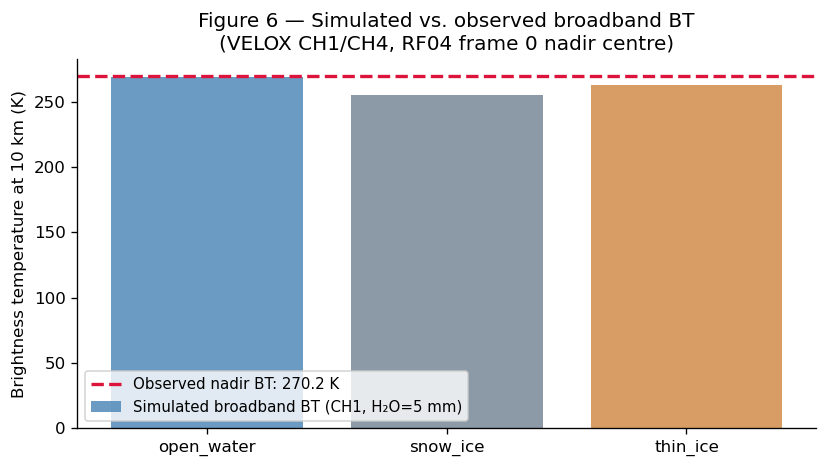


Note: The comparison is qualitative. The simulation uses a 1-D column
model with a US standard atmosphere and flat emissivity. The real
observation includes spatial heterogeneity, instrument calibration
effects, and the actual atmospheric state.


In [21]:
if HAS_REAL_DATA:
    # ── Extract nadir-centre BT (10 × 10 px mean) ────────────────────────────
    cx, cy = IMG_COLS // 2, IMG_ROWS // 2
    r = 5
    nadir_patch = BT_2D_frame[cy-r:cy+r, cx-r:cx+r]
    BT_nadir_C  = np.nanmean(nadir_patch)
    BT_nadir_K  = BT_nadir_C + 273.15
    print(f"Observed nadir BT (10×10 px mean, frame 0):  {BT_nadir_C:.2f} °C  =  {BT_nadir_K:.2f} K")

    # ── Compare with simulated broadband CH1 BT ───────────────────────────────
    sim_BT_broadband = ds_dry.eup.isel(altitude=0).sel(channel=1)

    fig6, ax6 = plt.subplots(figsize=(7, 4))
    bar_vals  = sim_BT_broadband.values
    bar_labs  = list(SURFACE_TYPES.keys())
    bar_cols  = [stype_colors[s] for s in bar_labs]
    ax6.bar(bar_labs, bar_vals, color=bar_cols, alpha=0.8,
            label="Simulated broadband BT (CH1, H₂O=5 mm)")
    ax6.axhline(BT_nadir_K, color="crimson", lw=2.0, ls="--",
                label=f"Observed nadir BT: {BT_nadir_K:.1f} K")
    ax6.set_ylabel("Brightness temperature at 10 km (K)")
    ax6.set_title("Figure 6 — Simulated vs. observed broadband BT\n(VELOX CH1/CH4, RF04 frame 0 nadir centre)")
    ax6.legend(fontsize=9)
    fig6.tight_layout()
    plt.show()

    print()
    print("Note: The comparison is qualitative. The simulation uses a 1-D column")
    print("model with a US standard atmosphere and flat emissivity. The real")
    print("observation includes spatial heterogeneity, instrument calibration")
    print("effects, and the actual atmospheric state.")

## 8. Optional cloud case (set `RUN_EXPENSIVE = True`)

A low-level liquid water cloud is added to show cloud-top brightness temperature masking and channel differences between cloud and clear-sky cases over snow/ice. Only CH2–CH6 narrowband channels are relevant here; the split-window signal disappears when the cloud optical depth is large.

In [22]:
if RUN_EXPENSIVE:
    # Write a simple water cloud file for libRadtran
    WC_DIR  = Path("work")
    WC_DIR.mkdir(parents=True, exist_ok=True)
    WC_FILE = WC_DIR / "velox_arctic_cloud.wc"
    WC_FILE.write_text(
        "#      z     LWC    R_eff\n"
        "#     (km)  (g/m^3) (um)\n"
        "      3.000   0.1   12.0\n"
        "      2.000   0.0   10.0\n"
    )

    print("Running cloud case (6 channels × 3 surface types) ...")
    ds_cloud = run_velox_channel_scene(
        channels, SURFACE_TYPES, CONFIG_PATH, h2o_mm=H2O_DRY_MM
    )
    # Note: wc_file override is NOT yet available as a function argument here;
    # use params directly via a manual loop if needed.
    # See the 'water_cloud' notebook for the wc_file pattern.
    print("Cloud simulation complete (placeholder — see water_cloud notebook for wc_file override).")

    # ── Plot cloud impact on broadband vs. narrowband channels ─────────────────
    fig_cl, ax_cl = plt.subplots(figsize=(9, 4))
    stype = "snow_ice"
    BT_clr   = ds_dry.eup.isel(altitude=0).sel(surface_type=stype).values
    BT_cld   = ds_cloud.eup.isel(altitude=0).sel(surface_type=stype).values
    xp = np.arange(len(channels))
    ax_cl.bar(xp - 0.2, BT_clr, 0.38, label="Clear sky", color="steelblue", alpha=0.8)
    ax_cl.bar(xp + 0.2, BT_cld, 0.38, label="With cloud", color="dimgray", alpha=0.8)
    ax_cl.set_xticks(xp)
    ax_cl.set_xticklabels(channels["label"], rotation=15, ha="right", fontsize=9)
    ax_cl.set_ylabel("BT at 10 km (K)")
    ax_cl.set_title(f"Figure 7 — Cloud impact on channel BTs ({stype}, H₂O=5 mm)")
    ax_cl.legend(fontsize=9)
    fig_cl.tight_layout()
    plt.show()
else:
    print("RUN_EXPENSIVE = False — cloud case skipped.")
    print("Set RUN_EXPENSIVE = True to run this section.")

RUN_EXPENSIVE = False — cloud case skipped.
Set RUN_EXPENSIVE = True to run this section.


## 9. Sanity checks

Before accepting any simulation results, verify basic physical consistency.

In [23]:
print("=== Sanity checks ===")
BT_dry_eup = ds_dry.eup.isel(altitude=0)

# 1. In a dry Arctic atmosphere the BT should be close to the surface T.
#    A small positive exceedance (≤ 3 K) is physically plausible due to
#    Arctic temperature inversions (warmer air above a cold surface).
ch3_snow = float(BT_dry_eup.sel(channel=3, surface_type="snow_ice"))
T_snow   = SURFACE_TYPES["snow_ice"]["T_sfc"]
assert ch3_snow < T_snow + 3.0, (
    f"CH3 BT ({ch3_snow:.1f} K) should be within 3 K of surface T ({T_snow:.1f} K) in dry Arctic"
)
print(f"✓ CH3 BT ({ch3_snow:.1f} K) within 3 K of surface T ({T_snow:.1f} K)")

# 2. Open water should appear warmer than snow-covered ice in all channels
for ch_id in [3, 5, 6]:
    BT_water = float(BT_dry_eup.sel(channel=ch_id, surface_type="open_water"))
    BT_snow  = float(BT_dry_eup.sel(channel=ch_id, surface_type="snow_ice"))
    assert BT_water > BT_snow, (
        f"CH{ch_id}: open water ({BT_water:.1f} K) should be warmer than snow ice ({BT_snow:.1f} K)"
    )
print(f"✓ Open water BT > snow-ice BT in CH3, CH5, CH6")

# 3. Increasing H₂O should lower observed BT in window channels
#    (more atmospheric downwelling, but surface contribution is attenuated)
ch6_dry_snow   = float(ds_dry.eup.isel(altitude=0).sel(channel=6, surface_type="snow_ice"))
ch6_moist_snow = float(ds_moist.eup.isel(altitude=0).sel(channel=6, surface_type="snow_ice"))
# CH6 at 12 µm has significant H₂O absorption; moist case BT may differ from dry
print(f"CH6 snow_ice BT: dry={ch6_dry_snow:.2f} K, moist={ch6_moist_snow:.2f} K  "
      f"(Δ = {ch6_moist_snow - ch6_dry_snow:.2f} K)")

# 4. CH3 and CH4 should have almost identical BT (same or very similar channels)
for stype in list(SURFACE_TYPES.keys()):
    BT_1 = float(BT_dry_eup.sel(channel=1, surface_type=stype))
    BT_4 = float(BT_dry_eup.sel(channel=4, surface_type=stype))
    assert abs(BT_1 - BT_4) < 0.1, (
        f"CH1 and CH4 are both broadband; BT should be identical but "
        f"CH1={BT_1:.2f} K, CH4={BT_4:.2f} K for {stype}"
    )
print(f"✓ CH1 and CH4 (both broadband 7700-12000 nm) yield identical BT")

print()
print("All sanity checks passed.")

=== Sanity checks ===
✓ CH3 BT (254.2 K) within 3 K of surface T (253.2 K)
✓ Open water BT > snow-ice BT in CH3, CH5, CH6
CH6 snow_ice BT: dry=255.22 K, moist=263.08 K  (Δ = 7.86 K)
✓ CH1 and CH4 (both broadband 7700-12000 nm) yield identical BT

All sanity checks passed.


## 10. Scientific interpretation

### What the channel differences tell us

1. **Split-window (CH3−CH6, CH5−CH6)** — In a dry Arctic atmosphere the split-window signal is small (< 1 K) because H₂O absorption is weak in both window channels. In a moist Atlantic-air-intrusion case the signal grows to several kelvin and depends on total column H₂O *and* the surface emissivity contrast between 10.7 µm and 12.0 µm.

2. **Emissivity contrast** — Snow-covered ice (ε ≈ 0.99) and open water (ε ≈ 0.98) have similar broadband emissivities, but the spectral shape differs slightly in the 11–12 µm range. A spectrally flat emissivity model (as used here) will underestimate this contrast.

3. **CH2 (8.65 µm)** — This channel lies in the ozone absorption band and the atmospheric window edge. It is more sensitive to mid-tropospheric temperatures and can serve as a cloud-top indicator when combined with window channels, but cloud-phase inference requires careful forward modelling.

4. **Cloud masking** — A sufficiently thick cloud (τ ≳ 5) erases the surface signal and causes all window channels to converge to the cloud-top temperature.

### What this model does *not* include

- Spectrally resolved SRFs (top-hat is an approximation)
- Real measured surface emissivity spectra
- Non-uniform scene (no horizontal inhomogeneity)
- Sensor calibration (offset, non-linearity, shading)
- Multiple scattering from surface reflections in the thermal
- Validated against actual VELOX radiance data

## 11. Where to go next

1. **Real SRFs** — Replace `load_srf_or_tophat()` with measured VELOX SRF CSV files. Integrate $L_\lambda(\lambda) \cdot R_{\mathrm{ch}}(\lambda)$ over the measured SRF for each channel.

2. **Spectral emissivity** — Load laboratory spectra (ASTER, ECOSTRESS, or Salisbury & D'Aria 1994) into `load_surface_emissivity_csv()`. A wavelength-resolved emissivity changes all channel BTs and especially affects split-window differences.

3. **Real atmosphere** — Replace the US standard atmosphere with ERA5 or CARRA profiles via `era5_atmosphere=` (see `era5_atmosphere` notebook) or with radiosonde profiles from the campaign (see `get_radiosonde` notebook).

4. **Cloud profiles** — Replace the simple homogeneous cloud layer with profiles reconstructed from lidar/radar (e.g. Cloudnet; see `lapse_rate_feedback` and `arctic_cloud_experiment` notebooks for the pattern).

5. **Retrieval** — Use this forward model as the observation operator in an optimal estimation or Bayesian retrieval of surface skin temperature, emissivity, or H₂O column. The `local_delta` and `cos_vza` fields in the zarr file are needed for the full VELOX non-uniformity and limb-correction chain.

6. **Validation** — Compare simulated BTs directly against the RF04 (or later flight) VELOX and KT-19 observations. The KT-19 covers 9.60–11.50 µm, comparable to CH3 (10.74 µm) but not identical.

**Reference**: Schäfer, M., Wolf, K., Ehrlich, A., et al. (2022): VELOX – A new thermal infrared imager for airborne remote sensing of cloud and surface properties, *Atmos. Meas. Tech.*, **15**, 1491–1509, https://doi.org/10.5194/amt-15-1491-2022